# 附：Codes .{unnumbered}

> Tobit 之后：截断、两部模型与比例因变量：配图与模拟数据

> 本 Notebook 用于生成 `05_truncated_twopart_lec.ipynb` 所需的模拟数据和配图。主讲义不依赖这里的绘图细节。

生成文件包括：

- `./data/limitdep_alt_sim.csv`
- `./figs/limit_dep_alt_fig01_model_map.png`
- `./figs/limit_dep_alt_fig02_loan_amount_distribution.png`
- `./figs/limit_dep_alt_fig03_twopart_mechanism.png`
- `./figs/limit_dep_alt_fig04_censor_trunc_select.png`
- `./figs/limit_dep_alt_fig05_fractional_response.png`
- `./figs/limit_dep_alt_fig06_twopart_prediction.png`


In [11]:
# ============================================================
# 全局设置
# ============================================================

import os
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import statsmodels.api as sm
from scipy.stats import norm, beta as beta_dist
from scipy.special import expit

warnings.filterwarnings("ignore")

# 创建输出文件夹
os.makedirs("./figs", exist_ok=True)
os.makedirs("./data", exist_ok=True)

# 中文字体设置：Windows 优先使用 SimHei；其他系统尝试常见中文字体
if platform.system() == "Windows":
    FONT_FAMILY = "SimHei"
else:
    import matplotlib.font_manager as fm
    available = {f.name for f in fm.fontManager.ttflist}
    for candidate in ["Noto Sans CJK SC", "Microsoft YaHei", "SimHei", "Arial Unicode MS", "WenQuanYi Micro Hei", "DejaVu Sans"]:
        if candidate in available:
            FONT_FAMILY = candidate
            break
    else:
        FONT_FAMILY = "DejaVu Sans"

plt.rcParams["font.sans-serif"] = [FONT_FAMILY, "DejaVu Sans", "Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "figure.dpi": 150,
    "savefig.dpi": 220,
    "figure.facecolor": "white"
})

rng = np.random.default_rng(20260428)
print(f"当前使用字体: {FONT_FAMILY}")

当前使用字体: SimHei


In [12]:
# ============================================================
# 生成模拟数据：银行贷款金额、截断样本、比例因变量和计数结果
# ============================================================

n = 3000

# 企业基本特征
size = np.random.normal(0, 1, n)                         # 企业规模，标准化后的 log(total assets)
cash = np.clip(np.random.beta(2.0, 5.0, n), 0.01, 0.90)  # 现金持有率
lev = np.clip(np.random.beta(2.2, 3.8, n), 0.02, 0.95)   # 资产负债率
profit = np.random.normal(0, 0.55, n)                    # 盈利能力，标准化 ROA
collateral = np.clip(0.45 + 0.18 * size + np.random.normal(0, 0.22, n), 0.02, 0.98)
bankbranch = np.random.normal(0, 1, n)                   # 本地银行网点密度，标准化
policy_window = np.random.binomial(1, expit(-0.1 + 0.35 * bankbranch), n)  # 政银企对接窗口覆盖

# ------------------------------------------------------------
# Two-part model 主案例：是否取得银行贷款，以及贷款金额
# ------------------------------------------------------------
borrow_latent = (
    -0.45
    + 0.55 * size
    + 0.80 * cash
    - 0.95 * lev
    + 0.55 * profit
    + 0.80 * collateral
    + 0.38 * bankbranch
    + 0.42 * policy_window
    + np.random.normal(0, 1, n)
)

borrow = (borrow_latent > 0).astype(int)

ln_loan_amt_latent = (
    2.25
    + 0.55 * size
    + 0.25 * cash
    - 0.35 * lev
    + 0.25 * profit
    + 0.45 * collateral
    + 0.10 * bankbranch
    + np.random.normal(0, 0.55, n)
)

loan_amt = np.where(borrow == 1, np.exp(ln_loan_amt_latent), 0.0)
ln_loan_amt = np.where(borrow == 1, np.log(loan_amt), np.nan)

# ------------------------------------------------------------
# Truncated regression 示例：只观察到超过报告门槛的合同金额
# ------------------------------------------------------------
contract_latent = (
    1.50
    + 0.45 * size
    + 0.20 * collateral
    - 0.25 * lev
    + np.random.normal(0, 0.85, n)
)
report_threshold = 1.25
contract_observed = np.where(contract_latent > report_threshold, contract_latent, np.nan)
reported = (~np.isnan(contract_observed)).astype(int)

# ------------------------------------------------------------
# Fractional response 示例：绿色贷款占比，位于 [0,1]
# ------------------------------------------------------------
mu_share = expit(
    -0.85
    + 0.30 * size
    + 0.65 * cash
    - 0.55 * lev
    + 0.45 * profit
    + 0.35 * bankbranch
)
precision = 16
green_share = beta_dist.rvs(mu_share * precision, (1 - mu_share) * precision, random_state=20260428)
# 加入少量真实边界值，模拟实际比例变量中 0 和 1 的存在
green_share = np.where(np.random.rand(n) < 0.08, 0, green_share)
green_share = np.where(np.random.rand(n) < 0.03, 1, green_share)

# ------------------------------------------------------------
# 计数型扩展示例：绿色专利数量
# ------------------------------------------------------------
patent_mean = np.exp(-0.10 + 0.45 * size + 0.30 * cash - 0.25 * lev + 0.25 * profit)
innovate = np.random.binomial(1, expit(-0.50 + 0.55 * size + 0.45 * cash + 0.35 * profit), n)
green_patents = np.where(innovate == 1, np.random.poisson(patent_mean), 0)

df = pd.DataFrame({
    "firm_id": np.arange(1, n + 1),
    "size": size,
    "cash": cash,
    "lev": lev,
    "profit": profit,
    "collateral": collateral,
    "bankbranch": bankbranch,
    "policy_window": policy_window,
    "borrow_latent": borrow_latent,
    "borrow": borrow,
    "ln_loan_amt_latent": ln_loan_amt_latent,
    "loan_amt": loan_amt,
    "ln_loan_amt": ln_loan_amt,
    "contract_latent": contract_latent,
    "contract_observed": contract_observed,
    "reported": reported,
    "green_share": green_share,
    "green_patents": green_patents,
})

df.to_csv("./data/limitdep_alt_sim.csv", index=False)

print(df.shape)
print(df[["borrow", "loan_amt", "reported", "green_share", "green_patents"]].describe().round(3))


(3000, 18)
        borrow  loan_amt  reported  green_share  green_patents
count  3000.00  3000.000  3000.000     3000.000       3000.000
mean      0.49    10.022     0.592        0.302          0.484
std       0.50    16.507     0.492        0.213          0.956
min       0.00     0.000     0.000        0.000          0.000
25%       0.00     0.000     0.000        0.158          0.000
50%       0.00     0.000     1.000        0.274          0.000
75%       1.00    14.538     1.000        0.409          1.000
max       1.00   189.994     1.000        1.000          7.000


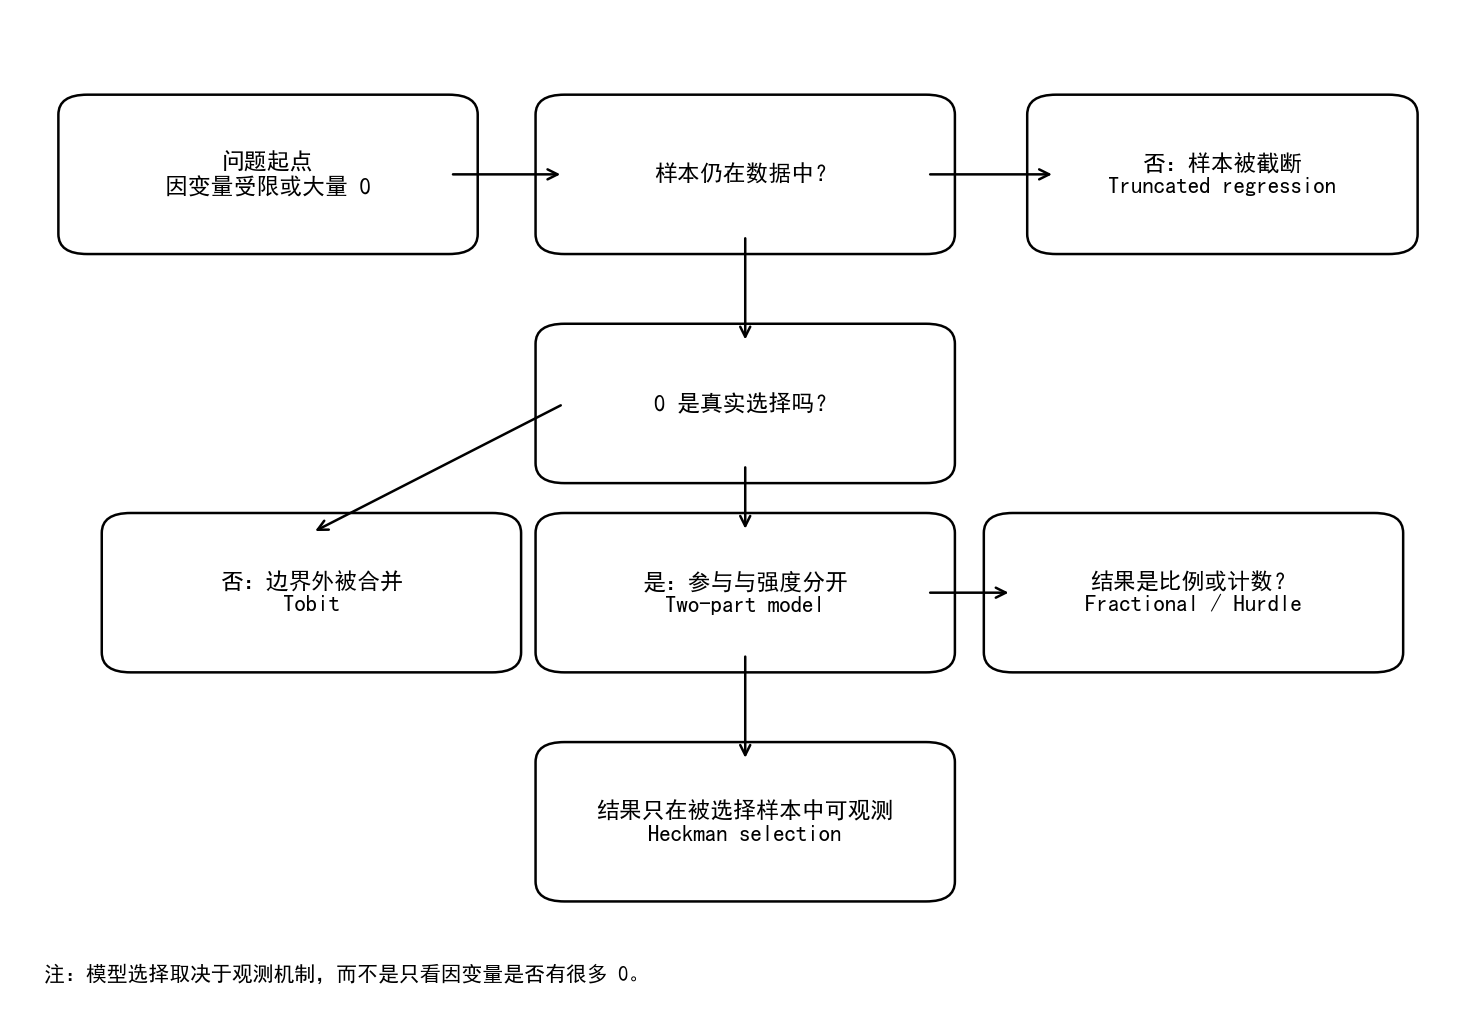

In [19]:
# ============================================================
# 图 1：受限因变量模型选择地图
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_axis_off()

boxes = [
    (0.05, 0.78, 0.25, 0.12, "问题起点\n因变量受限或大量 0"),
    (0.38, 0.78, 0.25, 0.12, "样本仍在数据中？"),
    (0.72, 0.78, 0.23, 0.12, "否：样本被截断\nTruncated regression"),
    (0.38, 0.55, 0.25, 0.12, "0 是真实选择吗？"),
    (0.08, 0.36, 0.25, 0.12, "否：边界外被合并\nTobit"),
    (0.38, 0.36, 0.25, 0.12, "是：参与与强度分开\nTwo-part model"),
    (0.69, 0.36, 0.25, 0.12, "结果是比例或计数？\nFractional / Hurdle"),
    (0.38, 0.13, 0.25, 0.12, "结果只在被选择样本中可观测\nHeckman selection"),
]

for x, y, w, h, text in boxes:
    rect = patches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=1.2,
        facecolor="white",
        edgecolor="black"
    )
    ax.add_patch(rect)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=11)

arrows = [
    ((0.30, 0.84), (0.38, 0.84)),
    ((0.63, 0.84), (0.72, 0.84)),
    ((0.505, 0.78), (0.505, 0.67)),
    ((0.505, 0.55), (0.505, 0.48)),
    ((0.38, 0.61), (0.205, 0.48)),
    ((0.63, 0.42), (0.69, 0.42)),
    ((0.505, 0.36), (0.505, 0.25)),
]

for start, end in arrows:
    ax.annotate(
        "", xy=end, xytext=start,
        arrowprops=dict(arrowstyle="->", lw=1.2)
    )

ax.text(0.02, 0.03, "注：模型选择取决于观测机制，而不是只看因变量是否有很多 0。", fontsize=10)
plt.tight_layout()
plt.savefig("./figs/limit_dep_alt_fig01_model_map.png", bbox_inches="tight")
plt.show()


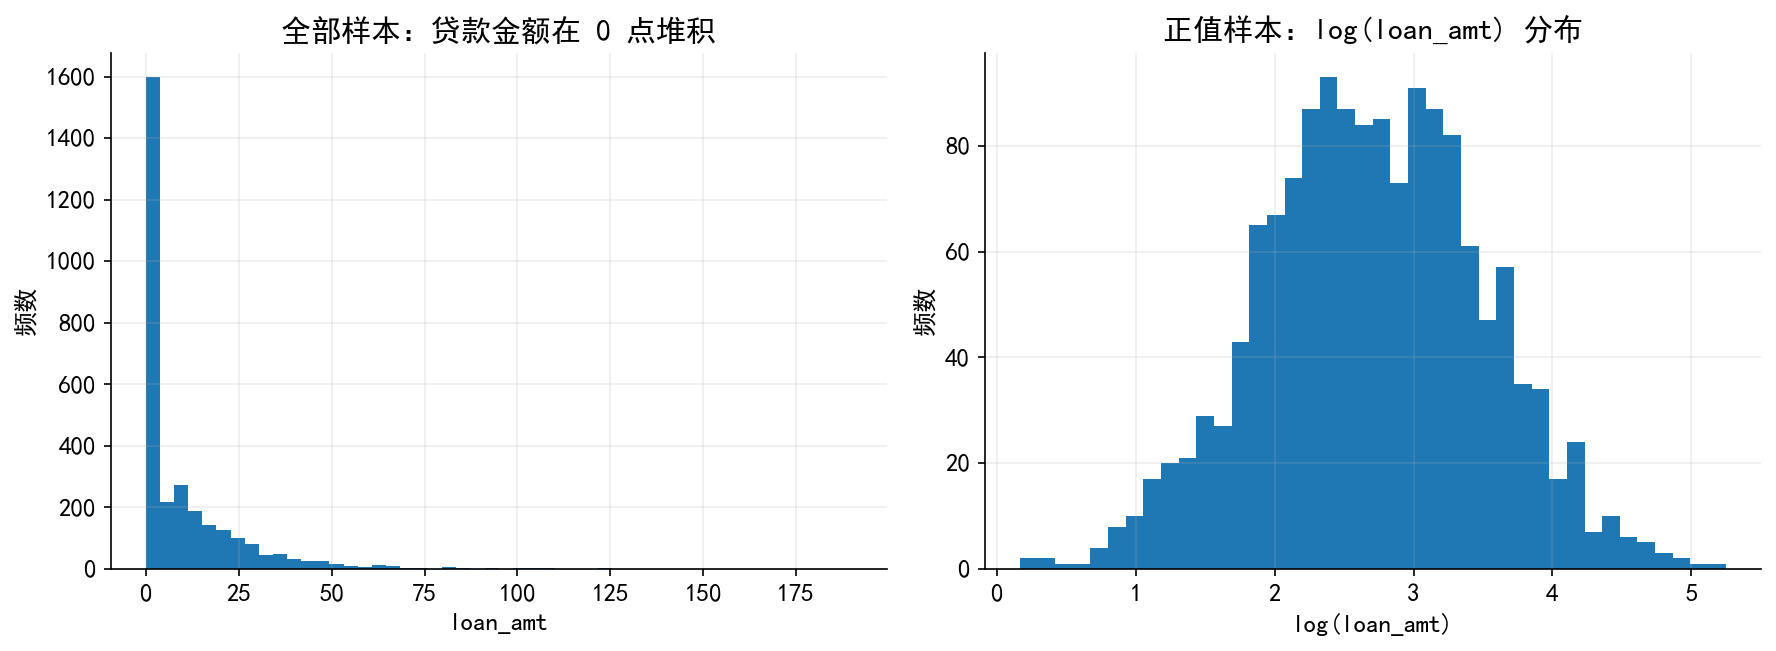

In [14]:
# ============================================================
# 图 2：贷款金额分布
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df["loan_amt"], bins=50)
axes[0].set_title("全部样本：贷款金额在 0 点堆积")
axes[0].set_xlabel("loan_amt")
axes[0].set_ylabel("频数")

positive = df.loc[df["loan_amt"] > 0, "loan_amt"]
axes[1].hist(np.log(positive), bins=40)
axes[1].set_title("正值样本：log(loan_amt) 分布")
axes[1].set_xlabel("log(loan_amt)")
axes[1].set_ylabel("频数")

plt.tight_layout()
plt.savefig("./figs/limit_dep_alt_fig02_loan_amount_distribution.png", bbox_inches="tight")
plt.show()


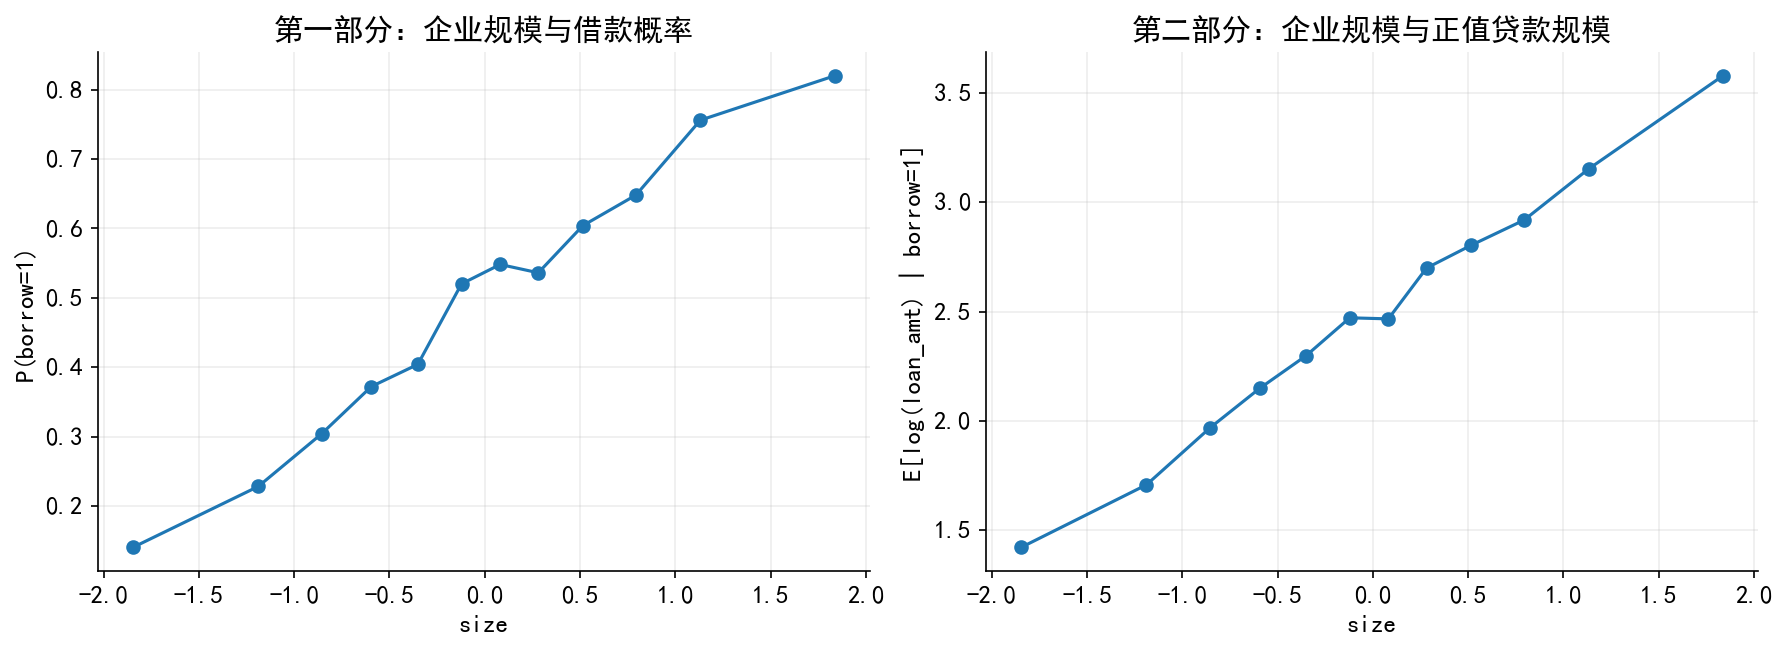

In [15]:
# ============================================================
# 图 3：Two-part 机制：是否借款与借款规模
# ============================================================

df_plot = df.copy()
df_plot["size_bin"] = pd.qcut(df_plot["size"], 12, duplicates="drop")
bin_stats = df_plot.groupby("size_bin", observed=True).agg(
    size_mid=("size", "mean"),
    borrow_rate=("borrow", "mean"),
    mean_log_amt=("ln_loan_amt", "mean"),
    mean_amt=("loan_amt", "mean")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(bin_stats["size_mid"], bin_stats["borrow_rate"], marker="o")
axes[0].set_title("第一部分：企业规模与借款概率")
axes[0].set_xlabel("size")
axes[0].set_ylabel("P(borrow=1)")

axes[1].plot(bin_stats["size_mid"], bin_stats["mean_log_amt"], marker="o")
axes[1].set_title("第二部分：企业规模与正值贷款规模")
axes[1].set_xlabel("size")
axes[1].set_ylabel("E[log(loan_amt) | borrow=1]")

plt.tight_layout()
plt.savefig("./figs/limit_dep_alt_fig03_twopart_mechanism.png", bbox_inches="tight")
plt.show()


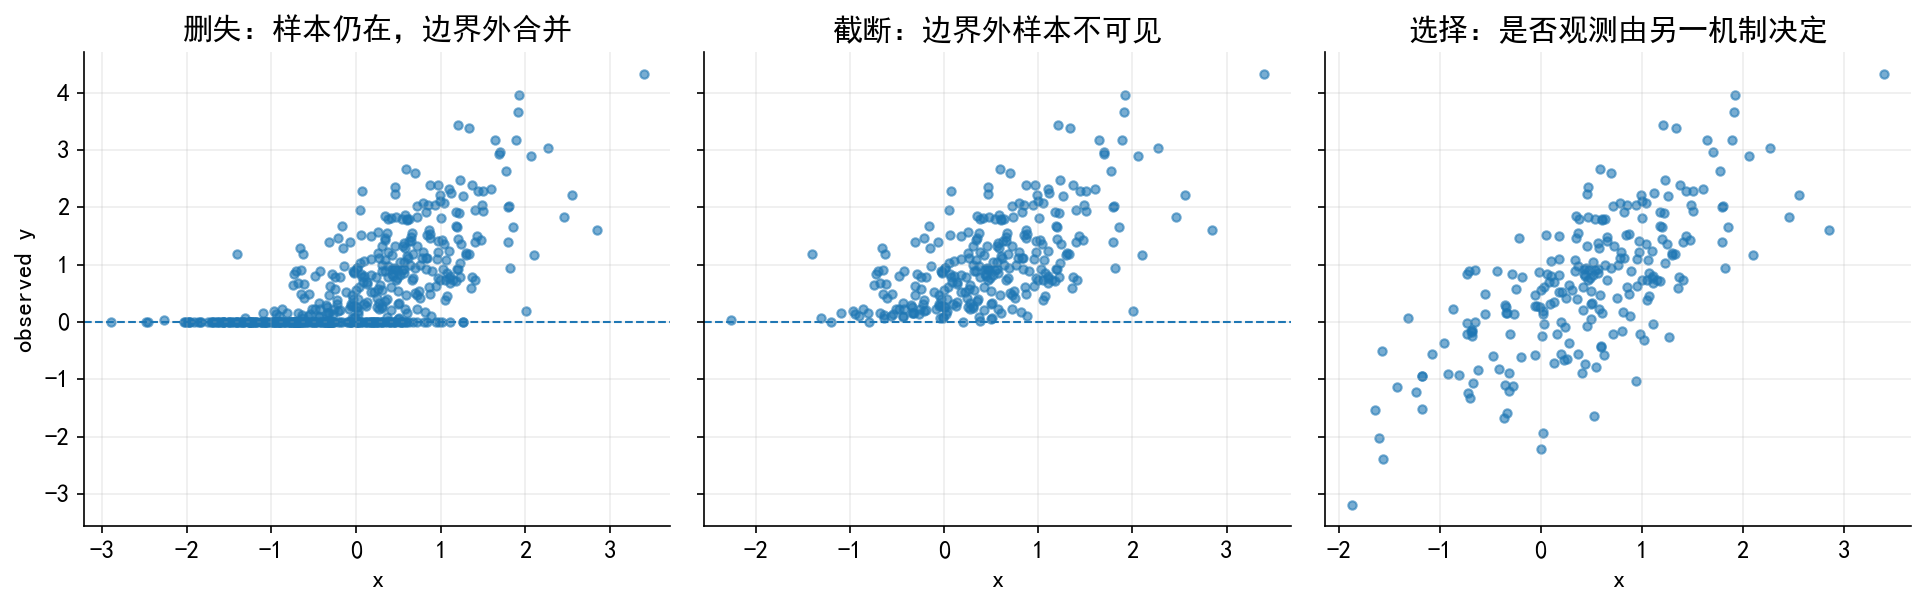

In [16]:
# ============================================================
# 图 4：删失、截断与样本选择的观测机制对比
# ============================================================

np.random.seed(20260428)
m = 500
x_demo = np.random.normal(0, 1, m)
y_latent_demo = 0.2 + 0.9 * x_demo + np.random.normal(0, 0.8, m)

y_censored = np.maximum(0, y_latent_demo)
mask_trunc = y_latent_demo > 0
select_latent = -0.1 + 0.8 * x_demo + np.random.normal(0, 1, m)
mask_select = select_latent > 0
y_select = np.where(mask_select, y_latent_demo, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)

axes[0].scatter(x_demo, y_censored, s=16, alpha=0.6)
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_title("删失：样本仍在，边界外合并")
axes[0].set_xlabel("x")
axes[0].set_ylabel("observed y")

axes[1].scatter(x_demo[mask_trunc], y_latent_demo[mask_trunc], s=16, alpha=0.6)
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].set_title("截断：边界外样本不可见")
axes[1].set_xlabel("x")

axes[2].scatter(x_demo[mask_select], y_select[mask_select], s=16, alpha=0.6)
axes[2].set_title("选择：是否观测由另一机制决定")
axes[2].set_xlabel("x")

plt.tight_layout()
plt.savefig("./figs/limit_dep_alt_fig04_censor_trunc_select.png", bbox_inches="tight")
plt.show()


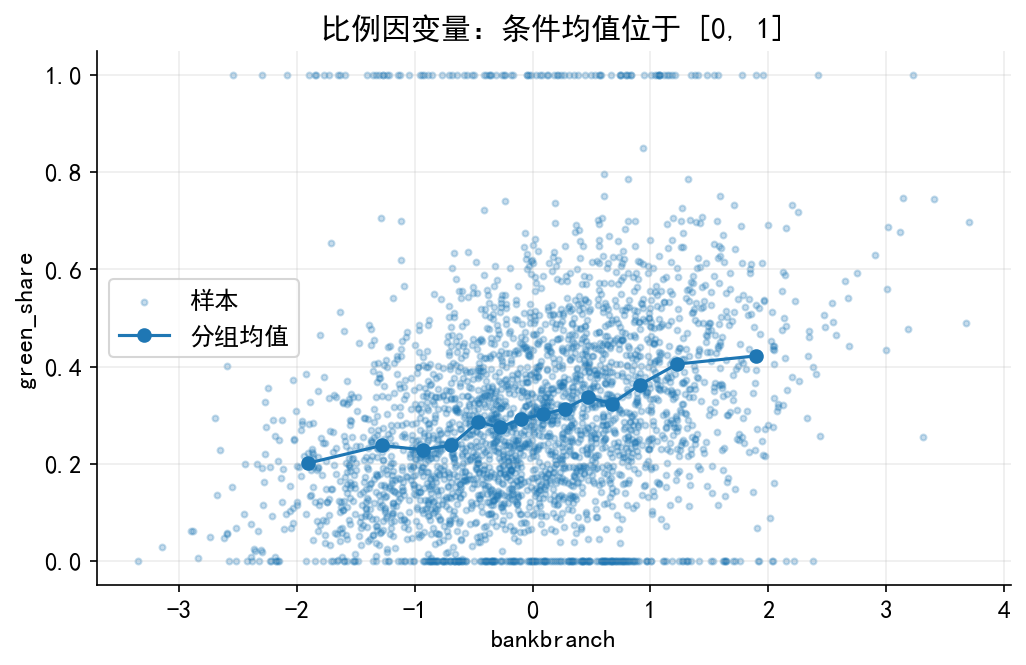

In [17]:
# ============================================================
# 图 5：比例因变量与 fractional response
# ============================================================

df_plot = df.copy()
df_plot["bank_bin"] = pd.qcut(df_plot["bankbranch"], 14, duplicates="drop")
share_stats = df_plot.groupby("bank_bin", observed=True).agg(
    bank_mid=("bankbranch", "mean"),
    share_mean=("green_share", "mean")
).reset_index()

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.scatter(df["bankbranch"], df["green_share"], s=8, alpha=0.25, label="样本")
ax.plot(share_stats["bank_mid"], share_stats["share_mean"], marker="o", label="分组均值")
ax.set_title("比例因变量：条件均值位于 [0, 1]")
ax.set_xlabel("bankbranch")
ax.set_ylabel("green_share")
ax.set_ylim(-0.05, 1.05)
ax.legend()
plt.tight_layout()
plt.savefig("./figs/limit_dep_alt_fig05_fractional_response.png", bbox_inches="tight")
plt.show()


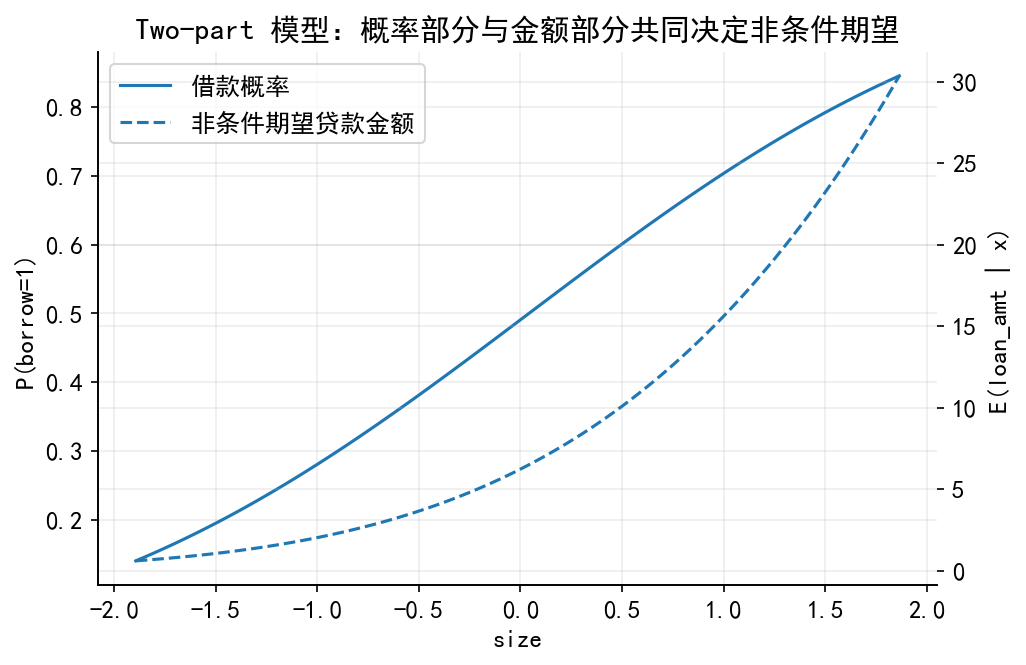

In [18]:
# ============================================================
# 图 6：Two-part 模型的非条件预测
# ============================================================

# 第一部分：Probit 估计是否借款
Z = sm.add_constant(df[["size", "cash", "lev", "profit", "collateral", "bankbranch", "policy_window"]])
probit_res = sm.Probit(df["borrow"], Z).fit(disp=False)

# 第二部分：正值样本上估计 log(loan_amt)
df_pos = df.loc[df["borrow"] == 1].copy()
X_pos = sm.add_constant(df_pos[["size", "cash", "lev", "profit", "collateral", "bankbranch"]])
log_amt_res = sm.OLS(df_pos["ln_loan_amt"], X_pos).fit()

# 预测：保持其他变量在均值，只改变 size
size_grid = np.linspace(df["size"].quantile(0.03), df["size"].quantile(0.97), 100)
base = df[["cash", "lev", "profit", "collateral", "bankbranch", "policy_window"]].mean()

grid_first = pd.DataFrame({
    "const": 1.0,
    "size": size_grid,
    "cash": base["cash"],
    "lev": base["lev"],
    "profit": base["profit"],
    "collateral": base["collateral"],
    "bankbranch": base["bankbranch"],
    "policy_window": base["policy_window"],
})

grid_second = grid_first.drop(columns=["policy_window"])

pred_prob = probit_res.predict(grid_first)
sigma_hat = log_amt_res.resid.std(ddof=int(log_amt_res.df_model) + 1)
pred_positive_amt = np.exp(log_amt_res.predict(grid_second) + 0.5 * sigma_hat**2)
pred_uncond_amt = pred_prob * pred_positive_amt

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(size_grid, pred_prob, label="借款概率")
ax.set_xlabel("size")
ax.set_ylabel("P(borrow=1)")

ax2 = ax.twinx()
ax2.plot(size_grid, pred_uncond_amt, linestyle="--", label="非条件期望贷款金额")
ax2.set_ylabel("E(loan_amt | x)")

lines = ax.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax.legend(lines, labels, loc="upper left")

ax.set_title("Two-part 模型：概率部分与金额部分共同决定非条件期望")
plt.tight_layout()
plt.savefig("./figs/limit_dep_alt_fig06_twopart_prediction.png", bbox_inches="tight")
plt.show()


生成上述文件后，即可运行 `05_truncated_twopart_lec.ipynb`。
